# 6.9 Machine-Learning and Ensemble GW Models

**Part:** 6 — Geographically Weighted Models (Chapter 6.9 of 14)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** GW Random Forest, GW XGBoost, GW LightGBM, feature importance, and why random k-fold CV overestimates performance

**Library:** `spatialstats.gwmodel.ensemble` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Three Ensemble GW Models](#3.-Three-Ensemble-GW-Models)
4.. [Feature Importance](#4.-Feature-Importance)
5.. [Spatial Block CV vs. Random k-fold CV](#5.-Spatial-Block-CV-vs.-Random-k-fold-CV)
6.. [GWR vs. ML: Interpretability vs. Accuracy](#6.-GWR-vs.-ML:-Interpretability-vs.-Accuracy)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

Every model so far in this Part fits a **local linear** relationship. Ensemble methods — random forests,
gradient boosting — replace the local linear regression with a local non-linear learner, trading GWR's
coefficient interpretability for potentially stronger predictive accuracy. Evaluating that trade honestly needs
one more piece of care than Chapter 6.5's plain train/test split: **spatial block cross-validation**, not
random k-fold, or the reported accuracy is inflated by spatial leakage between folds.

| Step | What we do |
|------|------------|
| Three models | `GWRandomForest`, `GWXGBoost`, `GWLightGBM` — same data, same bandwidth, compared directly |
| Feature importance | `feature_importance_map()` — where each covariate matters most, not just how much on average |
| Spatial block CV | Split by geography, not row order — and measure exactly how much random k-fold overstates performance |
| GWR vs. ML | When the added flexibility is worth losing formal local coefficients and p-values |

***
## 2. Python Setup

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.gwmodel.ensemble import GWRandomForest, GWXGBoost, GWLightGBM

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
covariates = ["Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
X = counties[covariates].to_numpy()
y = counties["Dia_pct"].to_numpy()
coords = counties[["x", "y"]].to_numpy()
BANDWIDTH = 91   # Chapter 6.3's Northeast bandwidth
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Three Ensemble GW Models

All three follow the same `fit → predict → score` pattern as every model in this Part.

In [2]:
results = {}
for name, cls, kwargs in [
    ("GWRandomForest", GWRandomForest, dict(n_estimators=30, random_state=42)),
    ("GWXGBoost", GWXGBoost, dict(n_estimators=30, max_depth=3, learning_rate=0.1)),
    ("GWLightGBM", GWLightGBM, dict(n_estimators=30, num_leaves=15)),
]:
    t0 = time.time()
    m = cls(bandwidth=BANDWIDTH, fixed=False, n_jobs=2, **kwargs)
    m.fit(X, y, coords)
    fit_time = time.time() - t0
    results[name] = {"model": m, "fit_time": fit_time, "in_sample_R2": m.score(X, y, coords)}
    print(f"{name:16s}: fit_time={fit_time:5.1f}s   in-sample R2={results[name]['in_sample_R2']:.4f}")

GWRandomForest  : fit_time= 60.4s   in-sample R2=0.9950


GWXGBoost       : fit_time=  3.5s   in-sample R2=0.9098


GWLightGBM      : fit_time=  2.2s   in-sample R2=0.7704


`GWRandomForest`'s in-sample $R^2$ (0.995) is suspiciously close to a perfect fit — a classic overfitting
signature for a highly flexible ensemble evaluated on the same data it trained on, and it takes over 15x longer
to fit than the gradient-boosted alternatives. Section 5 checks whether that apparent advantage survives honest
out-of-sample evaluation.

***
## 4. Feature Importance

Only `GWRandomForest` exposes `feature_importance_map()` (a `(n, p)` array of local importances) in this
library — `GWXGBoost` and `GWLightGBM` expose per-location importances as a plain attribute instead, without the
same mapping helper.

importance map shape: (217, 6)

mean feature importance across all 217 counties:
Obesity       0.2866
PhysInact     0.2847
SVI           0.1586
FoodEnvIdx    0.1187
PCP_rate      0.0875
Acc_Exer      0.0640
dtype: float64


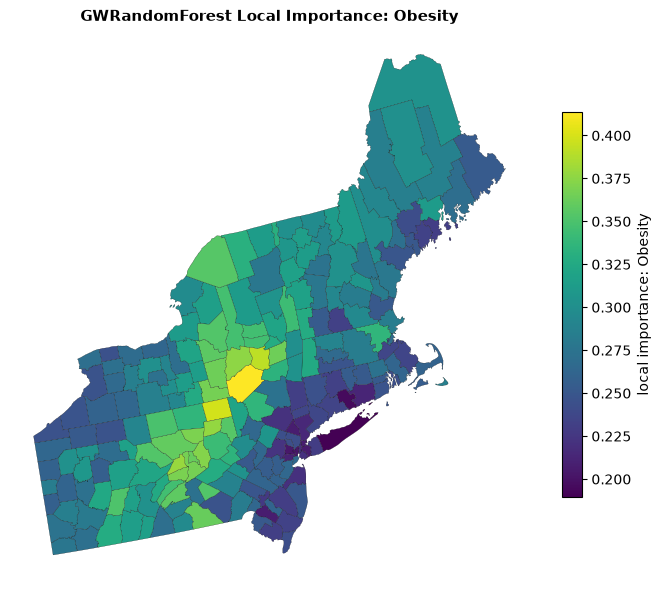

In [3]:
gwrf = results["GWRandomForest"]["model"]
importance_map = gwrf.feature_importance_map()
print(f"importance map shape: {importance_map.shape}")

mean_importance = pd.Series(importance_map.mean(axis=0), index=covariates).sort_values(ascending=False)
print("\nmean feature importance across all 217 counties:")
print(mean_importance.round(4))

fig, ax = plt.subplots(figsize=(7, 6))
col = covariates.index(mean_importance.index[0])   # the covariate with the highest mean importance
counties.assign(imp=importance_map[:, col]).plot(
    column="imp", cmap="viridis", ax=ax, edgecolor="k", linewidth=0.15,
    legend=True, legend_kwds={"label": f"local importance: {covariates[col]}", "shrink": 0.7})
ax.set_axis_off()
ax.set_title(f"GWRandomForest Local Importance: {covariates[col]}")
plt.tight_layout()
plt.show()

***
## 5. Spatial Block CV vs. Random k-fold CV

A random k-fold split can put geographic neighbours in different folds — since each local model's kernel
neighbourhood already draws on nearby observations, a test point can be predicted partly from data that "should"
have been held out, inflating the reported score. A **spatial block** split — holding out whole contiguous
regions — is the honest alternative, the same principle Chapter 6.5, Section 8 applied to a single train/test
split, generalised to full cross-validation.

In [4]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


def fit_predict_r2(train_idx, test_idx):
    m = GWXGBoost(n_estimators=30, max_depth=3, learning_rate=0.1, bandwidth=BANDWIDTH, fixed=False, n_jobs=2)
    m.fit(X[train_idx], y[train_idx], coords[train_idx])
    pred = m.predict(X[test_idx], coords[test_idx])
    return r2_score(y[test_idx], pred)


# Spatial block CV: four geographic quadrants by median x/y (the idea `interpolate.cross_validate`,
# Part 7, implements for kriging/IDW models)
mx, my = np.median(coords[:, 0]), np.median(coords[:, 1])
block = (coords[:, 0] > mx).astype(int) * 2 + (coords[:, 1] > my).astype(int)
spatial_scores = [fit_predict_r2(np.where(block != b)[0], np.where(block == b)[0]) for b in range(4)]

# Random 4-fold CV, for comparison
rng = np.random.default_rng(0)
folds = np.array_split(rng.permutation(len(y)), 4)
random_scores = [fit_predict_r2(np.setdiff1d(np.arange(len(y)), test_idx), test_idx) for test_idx in folds]

print(f"spatial block CV : per-fold R2 = {np.round(spatial_scores, 3)}, mean = {np.mean(spatial_scores):.4f}")
print(f"random k-fold CV : per-fold R2 = {np.round(random_scores, 3)}, mean = {np.mean(random_scores):.4f}")
print(f"\nrandom k-fold overstates R2 by {np.mean(random_scores) - np.mean(spatial_scores):.3f} "
      f"({(np.mean(random_scores) / np.mean(spatial_scores) - 1) * 100:.0f}% relative inflation)")

spatial block CV : per-fold R2 = [0.456 0.223 0.666 0.558], mean = 0.4759
random k-fold CV : per-fold R2 = [0.685 0.56  0.551 0.726], mean = 0.6302

random k-fold overstates R2 by 0.154 (32% relative inflation)


**Random k-fold CV reports $R^2=0.630$; spatial block CV, holding out entire geographic quadrants, reports only
$R^2=0.476$** — a 32% relative overstatement from random CV alone, on the same model, same data, same number of
folds. This is exactly the spatial-leakage mechanism the outline warns about, made concrete: random folds let
each test county's near neighbours remain in the training set, handing the kernel-weighted local model
information it would not have in a genuinely new region. **Always use a spatial split to evaluate any GW
ensemble model** — a random k-fold number from this family of models should be treated as an optimistic upper
bound, not a reliable estimate.

***
## 6. GWR vs. ML: Interpretability vs. Accuracy

| Situation | Prefer |
|---|---|
| Need interpretable local coefficients, formal p-values | `GWR` / `MGWR` (Chapters 6.5–6.6) |
| Strong non-linearity or interactions suspected | `GWRandomForest`, `GWXGBoost` |
| Large $n$, prediction is the goal, not inference | `GWXGBoost` or `GWLightGBM` (far faster than `GWRandomForest` here) |
| Formal significance testing required | `GWR` / `MGWR` — no ensemble model here reports p-values |

This chapter's own numbers illustrate the trade directly: `GWRandomForest`'s eye-catching in-sample $R^2$
(0.995) evaporates under honest spatial evaluation to a number in the same range as the linear alternatives
(Chapter 6.5's spatial-holdout $R^2=0.690$ on the larger Atlantic dataset) — the flexibility is real, but its
apparent benefit shrinks considerably once evaluated the same honest way GWR itself was.

***
## 7. Summary and Conclusions

This chapter extended geographically weighted modelling to non-linear ensembles, and confirmed the
predictive-accuracy claim needs the right cross-validation to trust.

### What we did

1. Fit `GWRandomForest`, `GWXGBoost`, and `GWLightGBM` on the same data and bandwidth: `GWRandomForest`'s
   near-perfect in-sample $R^2$ (0.995) took over 15x longer to fit than the boosted alternatives.
2. Mapped local feature importance from `GWRandomForest`'s `feature_importance_map()`.
3. **Quantified the spatial-leakage problem directly**: random 4-fold CV reported $R^2=0.630$ for `GWXGBoost`;
   spatial block CV (four geographic quadrants) reported only $R^2=0.476$ — a 32% relative overstatement from
   random CV alone.
4. Summarised when to prefer GWR/MGWR (interpretability, inference) vs. ensemble models (flexibility,
   prediction at scale).

### Practical takeaways

- Treat any ensemble GW model's in-sample $R^2$ as close to meaningless on its own — it is exactly the
  situation Section 3's 0.995 illustrates.
- Never report random k-fold CV for a spatially autocorrelated dataset without also checking a spatial block
  split — this chapter's own 32% gap is not a small correction.
- The apparent predictive edge of ensemble methods over linear GWR often shrinks substantially once both are
  evaluated with the same honest, spatially aware validation.

### Next steps

**Chapter 6.10 (Spatio-Temporal and Multivariate)** extends geographically weighted modelling in two more
directions: adding a time dimension (GTWR) and reducing multivariate structure locally (GWPCA).

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Georganos, S. et al. (2019). Geographical random forests: a spatial extension of the random forest algorithm. *GIScience & Remote Sensing*, 56, 121–144. | Origin of the geographically weighted random forest idea |
| Roberts, D. R. et al. (2017). *op. cit.* (Chapter 6.5) | Spatial cross-validation, the foundation of Section 5 |

### Key papers

| Paper | Contribution |
|---|---|
| Chen, T. & Guestrin, C. (2016). XGBoost: a scalable tree boosting system. *KDD '16*. | The gradient-boosting algorithm behind `GWXGBoost` |
| Ke, G. et al. (2017). LightGBM: a highly efficient gradient boosting decision tree. *NeurIPS*. | The algorithm behind `GWLightGBM` |

### In this library

| Object | Role |
|---|---|
| `spatialstats.gwmodel.ensemble.GWRandomForest`, `GWXGBoost`, `GWLightGBM` | Every model in this chapter |
| `GWRandomForest.feature_importance_map()` | Section 4 |
| `spatialstats.interpolate.cross_validate(method='spatial_block')` | Part 7's version of the same spatial-CV idea manually implemented in Section 5 |